                  id           Age  Academic Pressure  Work Pressure  \
count   27901.000000  27901.000000       27901.000000   27901.000000   
mean    70442.149421     25.822300           3.141214       0.000430   
std     40641.175216      4.905687           1.381465       0.043992   
min         2.000000     18.000000           0.000000       0.000000   
25%     35039.000000     21.000000           2.000000       0.000000   
50%     70684.000000     25.000000           3.000000       0.000000   
75%    105818.000000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27901.000000        27901.000000      27901.000000      27901.000000   
mean       7.656104            2.943837          0.000681          7.156984   
std        1.470707            1.361148          0.044394          3.707642   
min        0.000000            0.00

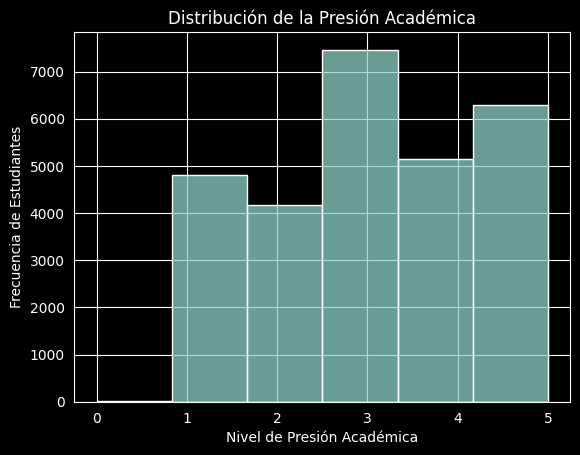

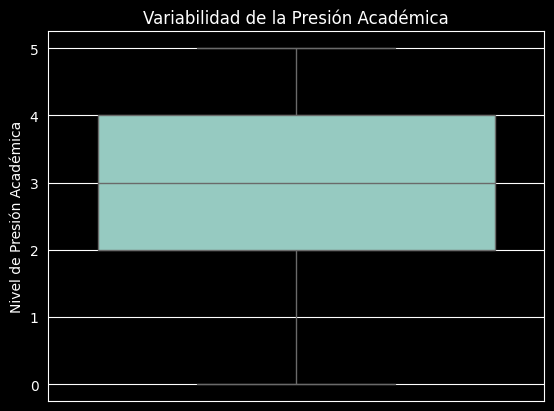

DISTRIBUCION DE EDADES


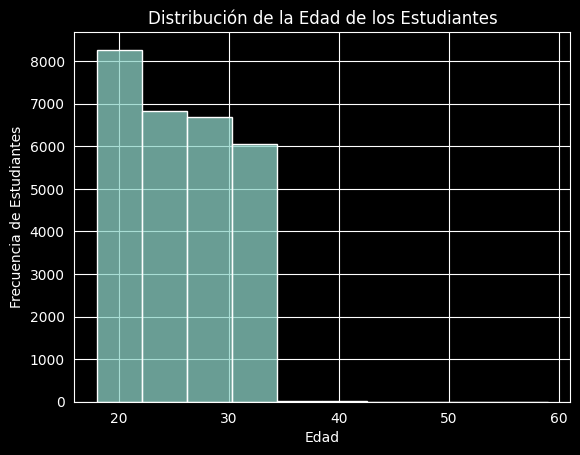

PROMEDIO DE NOTAS


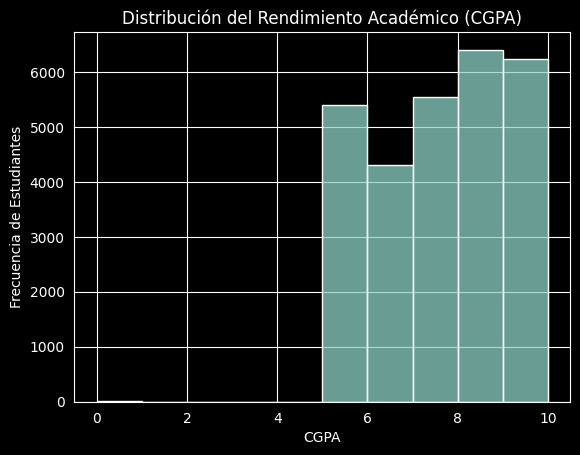

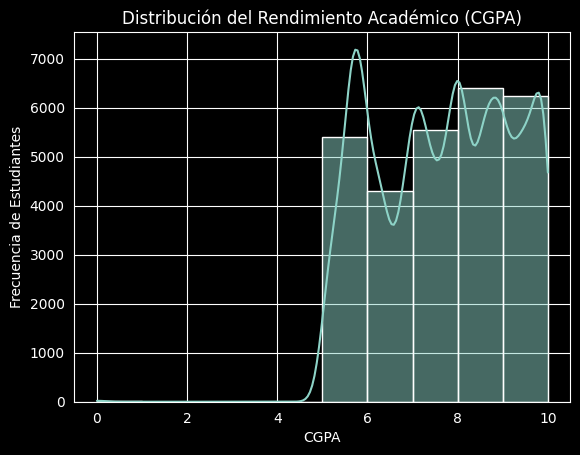

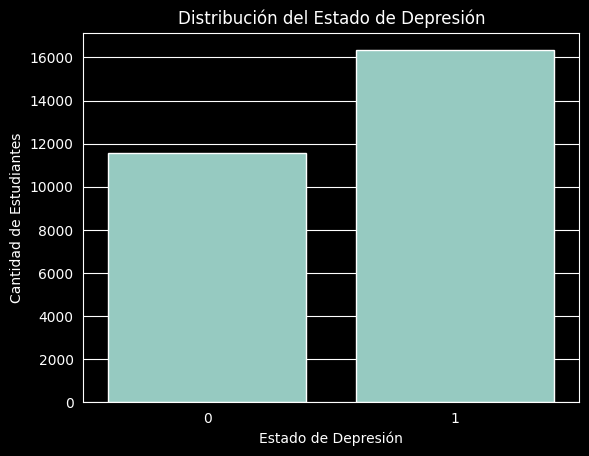

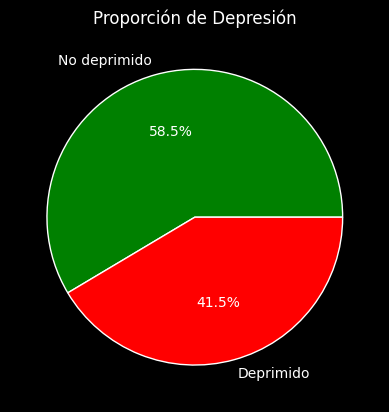

RELACION ENTRE DOS VARIABLES


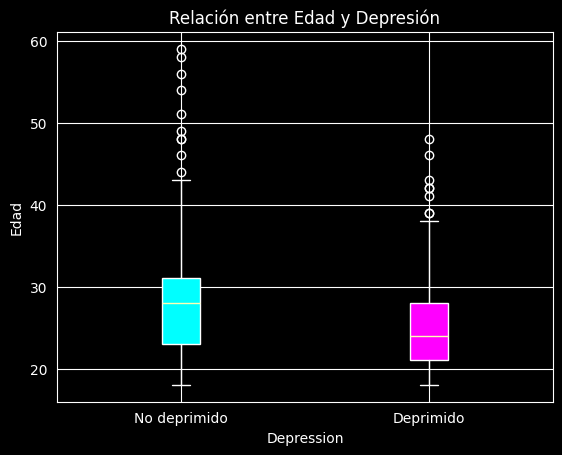

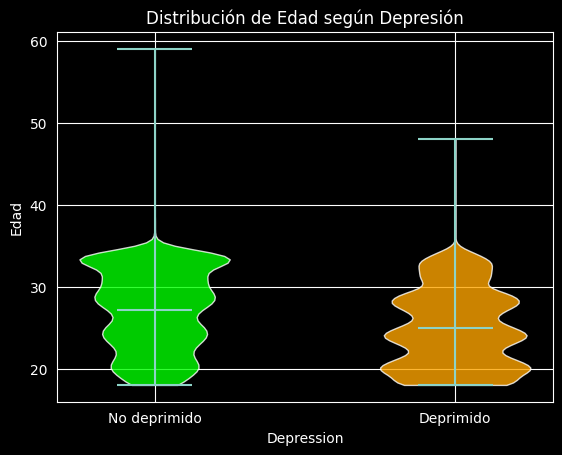

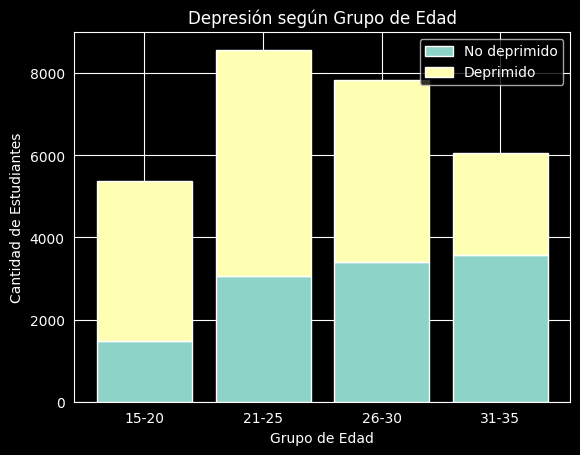

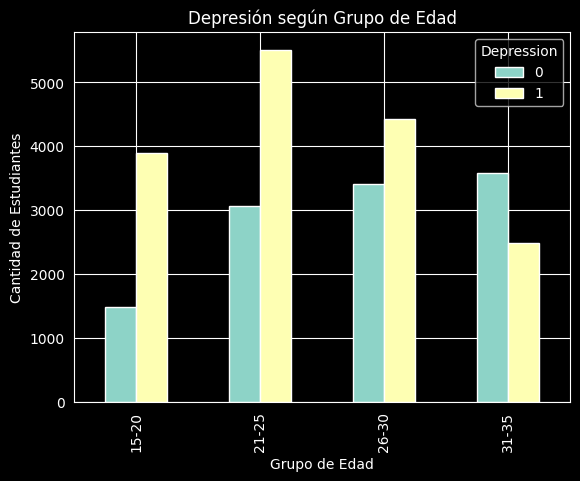

GENERO VS DEPRESION


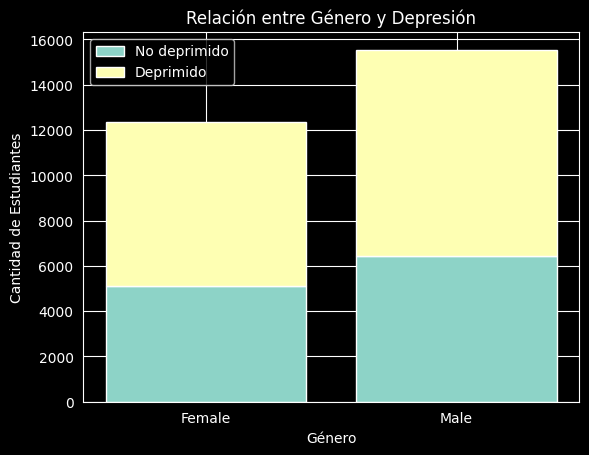

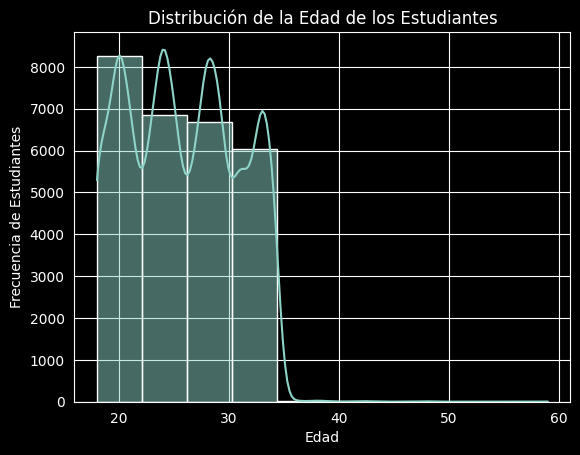

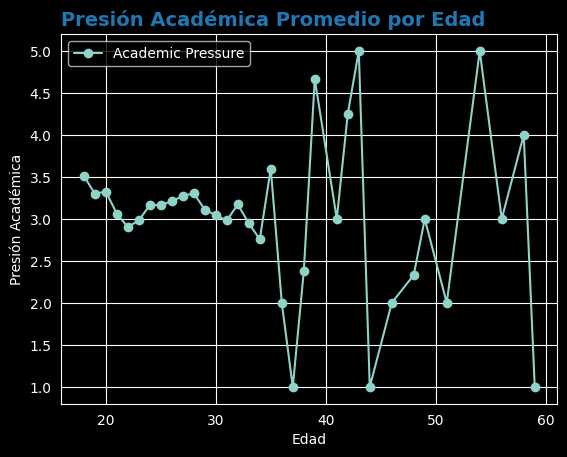

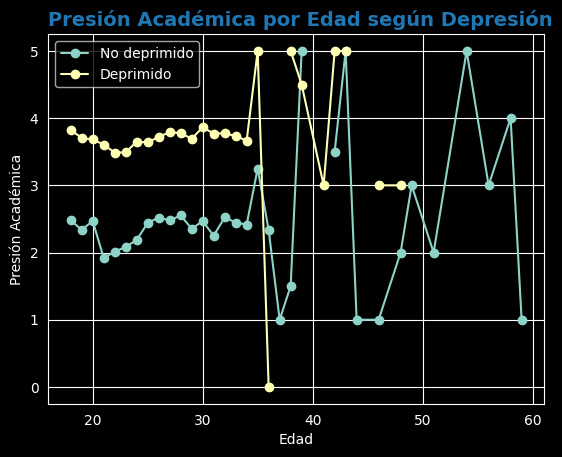

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression',
       'Age Group'],
      dtype='str')


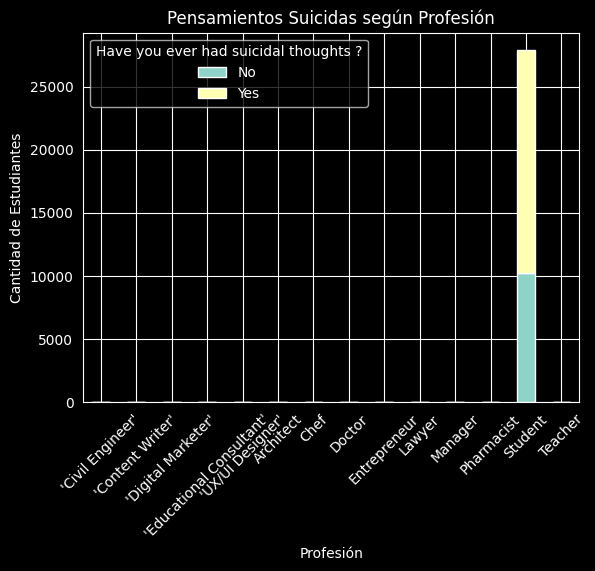

<Axes: xlabel='Gender', ylabel='count'>

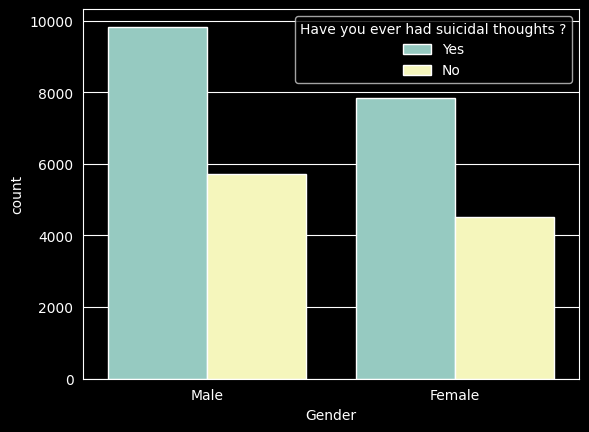

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_depression_dataset.csv')
df.head()

#TODO: 3.- Revise el contenido del dataSET, e identifique las columnas numéricas y muestre las estadísticas básicas de cada columna

numeric_cols = df.select_dtypes(include=['int64', 'float64'])
print(numeric_cols.describe())

print(df.info())


# --- Academic Pressure ---
print('DISTRIBUCION DE PRESION ACADEMICA')
plt.figure()
sns.histplot(df['Academic Pressure'], bins=6)

plt.title('Distribución de la Presión Académica')
plt.xlabel('Nivel de Presión Académica')
plt.ylabel('Frecuencia de Estudiantes')

plt.show()

plt.figure()
sns.boxplot(y=df['Academic Pressure'])

plt.title('Variabilidad de la Presión Académica')
plt.ylabel('Nivel de Presión Académica')

plt.show()
#EDAD
print('DISTRIBUCION DE EDADES')
plt.figure()
sns.histplot(df['Age'], bins=10)

plt.title('Distribución de la Edad de los Estudiantes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Estudiantes')

plt.show()


#PROMEDIO DE NOTAS
print('PROMEDIO DE NOTAS')
plt.figure()
sns.histplot(df['CGPA'], bins=10)

plt.title('Distribución del Rendimiento Académico (CGPA)')
plt.xlabel('CGPA')
plt.ylabel('Frecuencia de Estudiantes')

plt.show()

plt.figure()
sns.histplot(df['CGPA'], bins=10, kde=True)

plt.title('Distribución del Rendimiento Académico (CGPA)')
plt.xlabel('CGPA')
plt.ylabel('Frecuencia de Estudiantes')

plt.show()
#FRECUENCIA DE DEPRESION
plt.figure()
sns.countplot(x='Depression', data=df)

plt.title('Distribución del Estado de Depresión')
plt.xlabel('Estado de Depresión')
plt.ylabel('Cantidad de Estudiantes')

plt.show()

freq = df['Depression'].value_counts()

fig, ax = plt.subplots()

ax.pie(
    freq.values,
    labels=['No deprimido', 'Deprimido'],   # 0 → 1
    autopct='%1.1f%%',
    colors=['green', 'red']
)

ax.set_title('Proporción de Depresión')

plt.show()
print("RELACION ENTRE DOS VARIABLES")

fig, ax = plt.subplots()

box = ax.boxplot(
    [
        df[df['Depression'] == 0]['Age'],
        df[df['Depression'] == 1]['Age']
    ],
    patch_artist=True
)

# Colores vividos
colors = ['cyan', 'magenta']

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Relación entre Edad y Depresión')
ax.set_xlabel('Depression')
ax.set_ylabel('Edad')
ax.set_xticklabels(['No deprimido', 'Deprimido'])

plt.show()


fig, ax = plt.subplots()

vp = ax.violinplot(
    [
        df[df['Depression'] == 0]['Age'],
        df[df['Depression'] == 1]['Age']
    ],
    showmeans=True
)

# Colores vividos
for body, color in zip(vp['bodies'], ['lime', 'orange']):
    body.set_facecolor(color)
    body.set_alpha(0.8)

ax.set_title('Distribución de Edad según Depresión')
ax.set_xlabel('Depression')
ax.set_ylabel('Edad')
ax.set_xticks([1, 2])
ax.set_xticklabels(['No deprimido', 'Deprimido'])

plt.show()


df['Age Group'] = pd.cut(
    df['Age'],
    bins=[15, 20, 25, 30, 35],
    labels=['15-20', '21-25', '26-30', '31-35']
)
freq = pd.crosstab(df['Age Group'], df['Depression'])
fig, ax = plt.subplots()

ax.bar(freq.index, freq[0], label='No deprimido')
ax.bar(freq.index, freq[1], bottom=freq[0], label='Deprimido')

ax.set_title('Depresión según Grupo de Edad')
ax.set_xlabel('Grupo de Edad')
ax.set_ylabel('Cantidad de Estudiantes')

ax.legend()

plt.show()

freq.plot(kind='bar')

plt.title('Depresión según Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Estudiantes')

plt.show()

print("GENERO VS DEPRESION")

freq_gender_dep = pd.crosstab(df['Gender'], df['Depression'])
fig, ax = plt.subplots()

ax.bar(freq_gender_dep.index, freq_gender_dep[0], label='No deprimido')
ax.bar(freq_gender_dep.index, freq_gender_dep[1],
       bottom=freq_gender_dep[0], label='Deprimido')

ax.set_title('Relación entre Género y Depresión')
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad de Estudiantes')

ax.legend()

plt.show()

plt.figure()
sns.histplot(df['Age'], bins=10, kde=True)

plt.title('Distribución de la Edad de los Estudiantes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Estudiantes')

plt.show()


mean_pressure = df.groupby('Age')['Academic Pressure'].mean()
fig, ax = plt.subplots()

ax.plot(mean_pressure.index, mean_pressure.values, marker='o', label='Academic Pressure')

ax.set_title(
    'Presión Académica Promedio por Edad',
    loc="left",
    fontdict={'fontweight': 'bold', 'color': 'tab:blue', 'fontsize': 14}
)

ax.set_xlabel('Edad')
ax.set_ylabel('Presión Académica')

ax.legend()

plt.show()

mean_pressure_dep = df.groupby(['Age', 'Depression'])['Academic Pressure'].mean().unstack()

fig, ax = plt.subplots()

ax.plot(mean_pressure_dep.index, mean_pressure_dep[0], marker='o', label='No deprimido')
ax.plot(mean_pressure_dep.index, mean_pressure_dep[1], marker='o', label='Deprimido')

ax.set_title(
    'Presión Académica por Edad según Depresión',
    loc="left",
    fontdict={'fontweight': 'bold', 'color': 'tab:blue', 'fontsize': 14}
)

ax.set_xlabel('Edad')
ax.set_ylabel('Presión Académica')

ax.legend()

plt.show()


print(df.columns)

freq_prof_suic = pd.crosstab(
    df['Profession'],
    df['Have you ever had suicidal thoughts ?']
)

freq_prof_suic.plot(kind='bar', stacked=True)

plt.title('Pensamientos Suicidas según Profesión')
plt.xlabel('Profesión')
plt.ylabel('Cantidad de Estudiantes')

plt.xticks(rotation=45)
plt.show()

sns.countplot(
    x='Gender',
    hue='Have you ever had suicidal thoughts ?',
    data=df
)


     Country   Region  Year Water Source Type  Contaminant Level (ppm)  \
0     Mexico    North  2015              Lake                     6.06   
1     Brazil     West  2017              Well                     5.24   
2  Indonesia  Central  2022              Pond                     0.24   
3    Nigeria     East  2016              Well                     7.91   
4     Mexico    South  2005              Well                     0.12   

   pH Level  Turbidity (NTU)  Dissolved Oxygen (mg/L)  Nitrate Level (mg/L)  \
0      7.12             3.93                     4.28                  8.28   
1      7.84             4.79                     3.86                 15.74   
2      6.43             0.79                     3.42                 36.67   
3      6.71             1.96                     3.12                 36.92   
4      8.16             4.22                     9.15                 49.35   

   Lead Concentration (µg/L)  ...  Cholera Cases per 100,000 people  \
0        

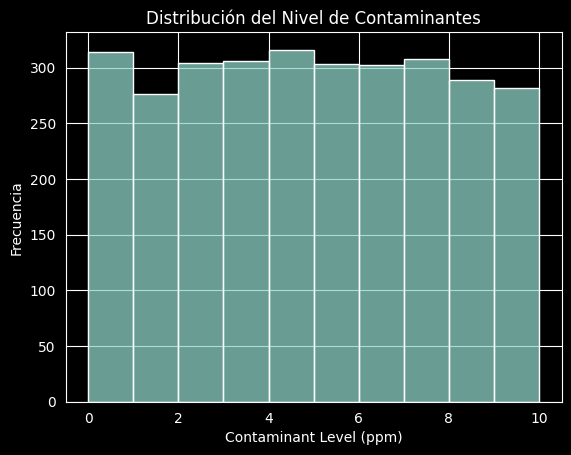


--- GRÁFICO 2: VARIABILIDAD DEL CONTEO DE BACTERIAS ---
El boxplot permite visualizar la dispersión del conteo bacteriano. Es útil para detectar valores atípicos, rango intercuartílico y tendencias de concentración.


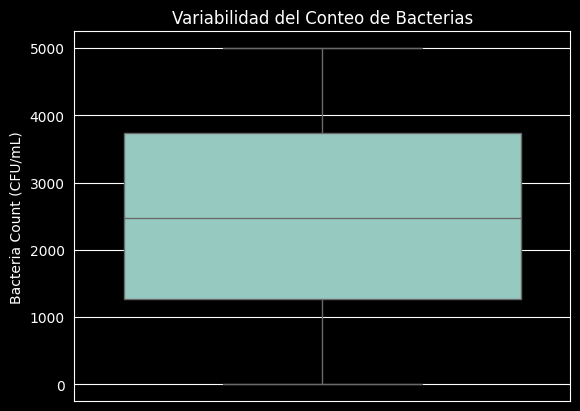


--- GRÁFICO 3: DISTRIBUCIÓN DE CASOS DIARREICOS ---
Este gráfico muestra la distribución de los casos diarreicos por 100,000 habitantes. Permite evaluar frecuencia, dispersión y forma de la variable epidemiológica.


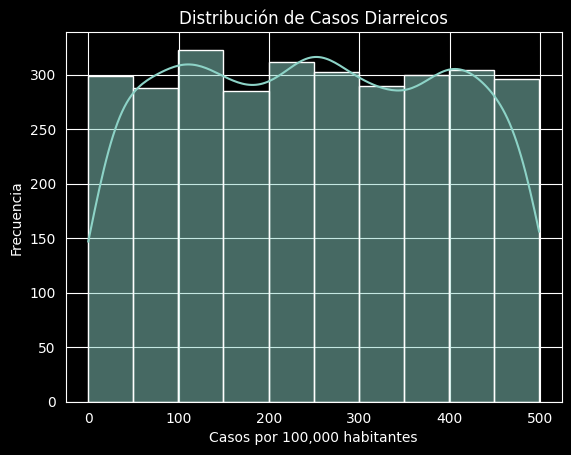


--- GRÁFICO 4: CASOS DIARREICOS POR REGIÓN ---
El barplot resume el promedio de casos diarreicos por región. Facilita comparaciones geográficas y detección de patrones regionales.


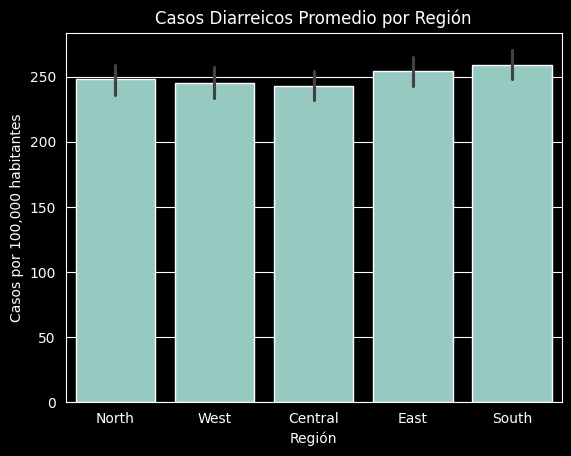


--- GRÁFICO 5: MÉTODOS DE TRATAMIENTO DE AGUA ---
El countplot muestra la frecuencia de cada método de tratamiento. Permite analizar predominancia tecnológica o prácticas más comunes.


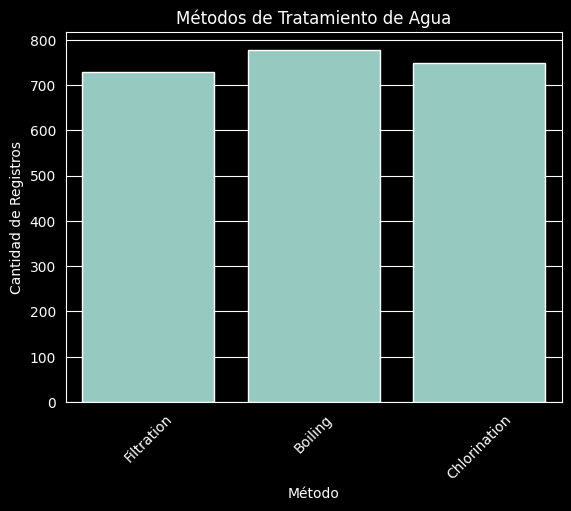


--- GRÁFICO 6: TENDENCIA DE CONTAMINANTES ---
El lineplot permite observar la evolución temporal del nivel de contaminantes. Ayuda a identificar tendencias, ciclos o variaciones.


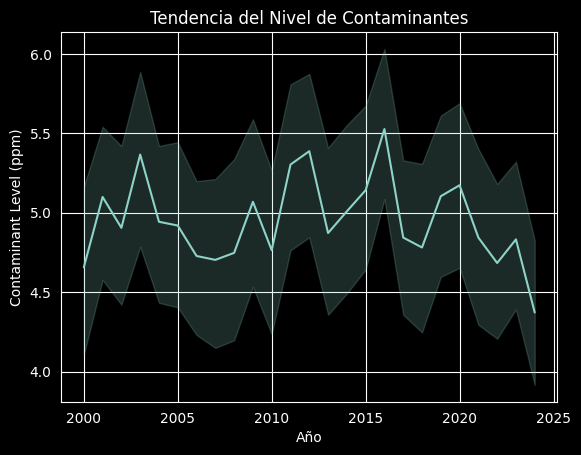


--- GRÁFICO 7: CONTAMINANTES vs CASOS DIARREICOS ---
El scatterplot evalúa la posible relación entre contaminación y afectación en salud. Permite detectar correlaciones o patrones.


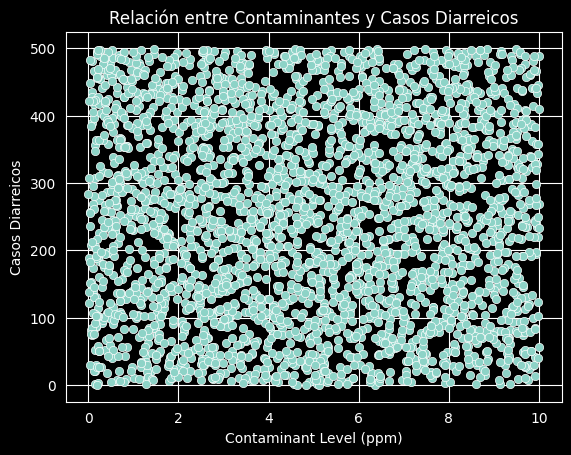


--- GRÁFICO 8: IMPACTO DEL CONTEO DE BACTERIAS ---
El regplot incorpora una línea de regresión para evaluar la relación entre bacterias y casos diarreicos, sugiriendo tendencias estadísticas.


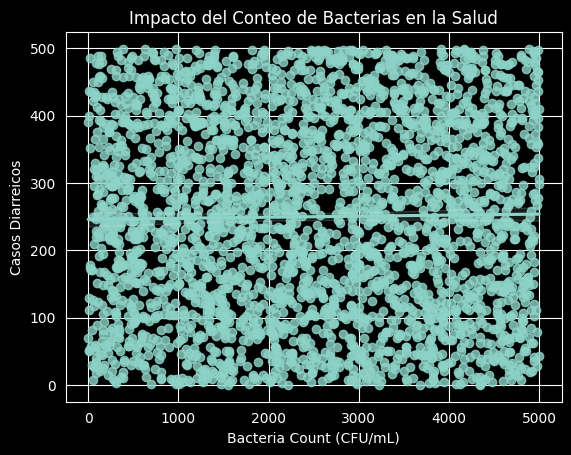


--- GRÁFICO 9: NIVELES DE CONTAMINACIÓN ---
El gráfico circular resume la proporción de registros según nivel de contaminación. Facilita la interpretación de composición relativa.


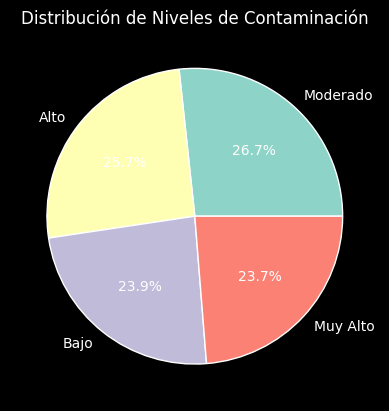


--- GRÁFICO 10: CONTAMINANTES SEGÚN TRATAMIENTO ---
El violinplot permite observar la distribución completa de contaminantes por método de tratamiento, incluyendo densidad y variabilidad.


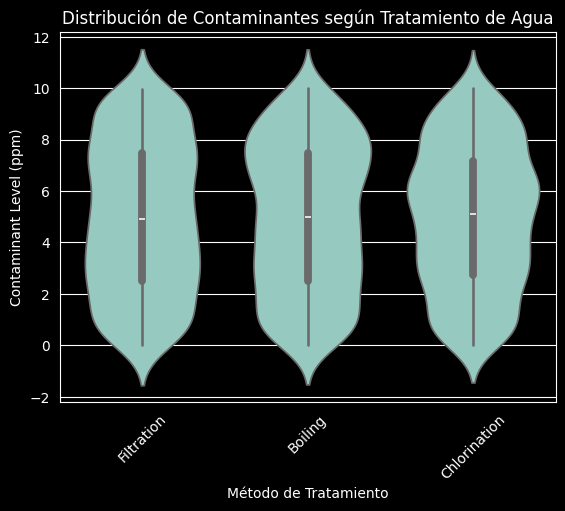


--- GRÁFICO 11: CONTAMINACIÓN POR REGIÓN ---
Este gráfico compara el promedio de contaminación entre regiones, permitiendo detectar diferencias espaciales.


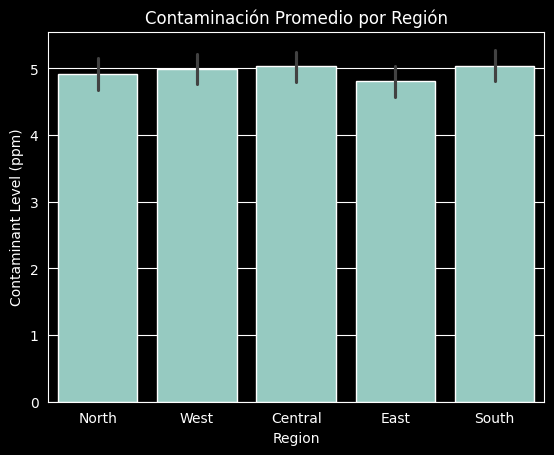


--- GRÁFICO 12: TRATAMIENTO DE AGUA POR REGIÓN ---
El gráfico apilado muestra la combinación de métodos de tratamiento en cada región, revelando patrones de infraestructura.


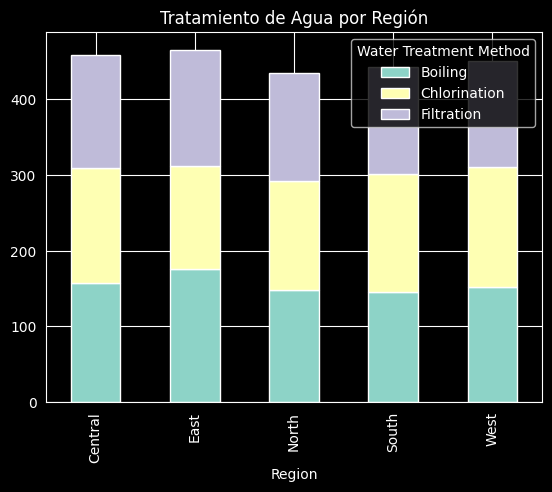

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('water_pollution_disease.csv')

print(df.head())

numeric_cols = df.select_dtypes(include=['int64', 'float64'])

print("COLUMNAS NUMÉRICAS:")
print(numeric_cols.columns)

print("\nESTADÍSTICAS BÁSICAS:")
print(numeric_cols.describe())


print("\n--- GRÁFICO 1: DISTRIBUCIÓN DE CONTAMINANTES ---")
print(
    "Este histograma muestra cómo se distribuyen los niveles de contaminantes "
    "en el conjunto de datos. Permite identificar concentraciones frecuentes, "
    "asimetrías y posibles valores extremos."
)

plt.figure()
sns.histplot(df['Contaminant Level (ppm)'], bins=10)

plt.title('Distribución del Nivel de Contaminantes')
plt.xlabel('Contaminant Level (ppm)')
plt.ylabel('Frecuencia')

plt.show()


print("\n--- GRÁFICO 2: VARIABILIDAD DEL CONTEO DE BACTERIAS ---")
print(
    "El boxplot permite visualizar la dispersión del conteo bacteriano. "
    "Es útil para detectar valores atípicos, rango intercuartílico y "
    "tendencias de concentración."
)

plt.figure()
sns.boxplot(y=df['Bacteria Count (CFU/mL)'])

plt.title('Variabilidad del Conteo de Bacterias')
plt.ylabel('Bacteria Count (CFU/mL)')

plt.show()


print("\n--- GRÁFICO 3: DISTRIBUCIÓN DE CASOS DIARREICOS ---")
print(
    "Este gráfico muestra la distribución de los casos diarreicos por "
    "100,000 habitantes. Permite evaluar frecuencia, dispersión y forma "
    "de la variable epidemiológica."
)

plt.figure()
sns.histplot(df['Diarrheal Cases per 100,000 people'], bins=10, kde=True)

plt.title('Distribución de Casos Diarreicos')
plt.xlabel('Casos por 100,000 habitantes')
plt.ylabel('Frecuencia')

plt.show()


print("\n--- GRÁFICO 4: CASOS DIARREICOS POR REGIÓN ---")
print(
    "El barplot resume el promedio de casos diarreicos por región. "
    "Facilita comparaciones geográficas y detección de patrones regionales."
)

plt.figure()
sns.barplot(
    x='Region',
    y='Diarrheal Cases per 100,000 people',
    data=df
)

plt.title('Casos Diarreicos Promedio por Región')
plt.xlabel('Región')
plt.ylabel('Casos por 100,000 habitantes')

plt.show()


print("\n--- GRÁFICO 5: MÉTODOS DE TRATAMIENTO DE AGUA ---")
print(
    "El countplot muestra la frecuencia de cada método de tratamiento. "
    "Permite analizar predominancia tecnológica o prácticas más comunes."
)

plt.figure()
sns.countplot(x='Water Treatment Method', data=df)

plt.title('Métodos de Tratamiento de Agua')
plt.xlabel('Método')
plt.ylabel('Cantidad de Registros')

plt.xticks(rotation=45)
plt.show()


print("\n--- GRÁFICO 6: TENDENCIA DE CONTAMINANTES ---")
print(
    "El lineplot permite observar la evolución temporal del nivel de "
    "contaminantes. Ayuda a identificar tendencias, ciclos o variaciones."
)

plt.figure()
sns.lineplot(
    x='Year',
    y='Contaminant Level (ppm)',
    data=df
)

plt.title('Tendencia del Nivel de Contaminantes')
plt.xlabel('Año')
plt.ylabel('Contaminant Level (ppm)')

plt.show()


print("\n--- GRÁFICO 7: CONTAMINANTES vs CASOS DIARREICOS ---")
print(
    "El scatterplot evalúa la posible relación entre contaminación y "
    "afectación en salud. Permite detectar correlaciones o patrones."
)

plt.figure()
sns.scatterplot(
    x='Contaminant Level (ppm)',
    y='Diarrheal Cases per 100,000 people',
    data=df
)

plt.title('Relación entre Contaminantes y Casos Diarreicos')
plt.xlabel('Contaminant Level (ppm)')
plt.ylabel('Casos Diarreicos')

plt.show()


print("\n--- GRÁFICO 8: IMPACTO DEL CONTEO DE BACTERIAS ---")
print(
    "El regplot incorpora una línea de regresión para evaluar la relación "
    "entre bacterias y casos diarreicos, sugiriendo tendencias estadísticas."
)

plt.figure()
sns.regplot(
    x='Bacteria Count (CFU/mL)',
    y='Diarrheal Cases per 100,000 people',
    data=df
)

plt.title('Impacto del Conteo de Bacterias en la Salud')
plt.xlabel('Bacteria Count (CFU/mL)')
plt.ylabel('Casos Diarreicos')

plt.show()


print("\n--- GRÁFICO 9: NIVELES DE CONTAMINACIÓN ---")
print(
    "El gráfico circular resume la proporción de registros según nivel "
    "de contaminación. Facilita la interpretación de composición relativa."
)

df['Contamination Level'] = pd.cut(
    df['Contaminant Level (ppm)'],
    bins=4,
    labels=['Bajo', 'Moderado', 'Alto', 'Muy Alto']
)

contamination_counts = df['Contamination Level'].value_counts()

plt.figure()
plt.pie(
    contamination_counts.values,
    labels=contamination_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribución de Niveles de Contaminación')

plt.show()


print("\n--- GRÁFICO 10: CONTAMINANTES SEGÚN TRATAMIENTO ---")
print(
    "El violinplot permite observar la distribución completa de contaminantes "
    "por método de tratamiento, incluyendo densidad y variabilidad."
)

sns.violinplot(
    x='Water Treatment Method',
    y='Contaminant Level (ppm)',
    data=df
)

plt.title('Distribución de Contaminantes según Tratamiento de Agua')
plt.xlabel('Método de Tratamiento')
plt.ylabel('Contaminant Level (ppm)')

plt.xticks(rotation=45)
plt.show()


print("\n--- GRÁFICO 11: CONTAMINACIÓN POR REGIÓN ---")
print(
    "Este gráfico compara el promedio de contaminación entre regiones, "
    "permitiendo detectar diferencias espaciales."
)

sns.barplot(
    x='Region',
    y='Contaminant Level (ppm)',
    data=df
)

plt.title('Contaminación Promedio por Región')
plt.show()


print("\n--- GRÁFICO 12: TRATAMIENTO DE AGUA POR REGIÓN ---")
print(
    "El gráfico apilado muestra la combinación de métodos de tratamiento "
    "en cada región, revelando patrones de infraestructura."
)

freq = pd.crosstab(df['Region'], df['Water Treatment Method'])

freq.plot(kind='bar', stacked=True)

plt.title('Tratamiento de Agua por Región')
plt.show()

In [1]:
import sys
import pandas as pd
from PyQt5.QtWidgets import (
    QApplication, QMainWindow, QWidget,
    QVBoxLayout, QListWidget, QListWidgetItem,
    QLabelyt
)
from PyQt5.QtCore import Qt

from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas
from matplotlib.figure import Figure


class PollutionApp(QMainWindow):
    def __init__(self):
        super().__init__()

        self.setWindowTitle("Contaminación por País")
        self.resize(900, 600)

        self.df = pd.read_csv("water_pollution_disease.csv")

        central = QWidget()
        self.setCentralWidget(central)

        layout = QVBoxLayout(central)

        layout.addWidget(QLabel("Selecciona hasta 5 países:"))

        self.list_widget = QListWidget()
        self.list_widget.itemChanged.connect(self.update_selection)
        layout.addWidget(self.list_widget)

        self.load_countries()

        self.figure = Figure()
        self.canvas = FigureCanvas(self.figure)
        layout.addWidget(self.canvas)

        self.selected_countries = []

        # 🎨 Colores más vividos
        self.colors = [
            "#FF5733",  # rojo intenso
            "#33C1FF",  # azul brillante
            "#33FF57",  # verde fuerte
            "#F3FF33",  # amarillo vibrante
            "#C700FF",  # púrpura intenso
        ]
        self.help_label = QLabel()
        self.help_label.setWordWrap(True)
        self.help_label.setStyleSheet("""
            QLabel {
                background-color: #f5f5f5;
                border: 1px solid #dddddd;
                padding: 8px;
                font-size: 11px;
            }
        """)

        self.help_label.setText(
            "INSTRUCCIONES DE USO:\n"
            "• Marca los países utilizando las casillas de selección.\n"
            "• Puedes seleccionar un máximo de cinco países simultáneamente.\n"
            "• El gráfico mostrará la contaminación promedio (ppm) por año.\n"
            "• Cada color representa un país distinto.\n"
            "• Usa esta visualización para comparar tendencias temporales.\n"
            "• Si no hay países seleccionados, el gráfico permanecerá vacío."
        )

        layout.addWidget(self.help_label)


    def load_countries(self):
        countries = sorted(self.df['Country'].unique())

        for country in countries:
            item = QListWidgetItem(country)
            item.setFlags(item.flags() | Qt.ItemIsUserCheckable)
            item.setCheckState(Qt.Unchecked)
            self.list_widget.addItem(item)

    def update_selection(self, item):
        checked = []

        for i in range(self.list_widget.count()):
            it = self.list_widget.item(i)
            if it.checkState() == Qt.Checked:
                checked.append(it.text())

        if len(checked) > 5:
            item.setCheckState(Qt.Unchecked)
            return

        self.selected_countries = checked
        self.update_chart()

    def update_chart(self):
        self.figure.clear()

        if not self.selected_countries:
            self.canvas.draw()
            return

        ax = self.figure.add_subplot(111)

        agg = (
            self.df[self.df['Country'].isin(self.selected_countries)]
            .groupby(['Year', 'Country'])['Contaminant Level (ppm)']
            .mean()
            .unstack()
        )

        agg.plot(
            kind='bar',
            ax=ax,
            color=self.colors  # ✅ colores intensos
        )

        ax.set_xlabel("Año")
        ax.set_ylabel("Contaminación (ppm)")
        ax.set_title("Niveles de Contaminación")
        ax.legend(title="País")

        self.canvas.draw()


if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = PollutionApp()
    window.show()
    sys.exit(app.exec_())

ImportError: DLL load failed while importing QtWidgets: No se puede encontrar el módulo especificado.

In [ ]:
import sys
import pandas as pd
from PyQt5.QtWidgets import (
    QApplication, QMainWindow, QWidget,
    QVBoxLayout, QListWidget, QListWidgetItem,
    QLabel
)
from PyQt5.QtCore import Qt

from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas
from matplotlib.figure import Figure


class DiseaseComparisonApp(QMainWindow):
    def __init__(self):
        super().__init__()

        self.setWindowTitle("Comparación Cólera vs Tifoidea")
        self.resize(1000, 700)

        self.df = pd.read_csv("water_pollution_disease.csv")

        central = QWidget()
        self.setCentralWidget(central)

        layout = QVBoxLayout(central)

        layout.addWidget(QLabel("Selecciona hasta 5 países:"))

        self.list_widget = QListWidget()
        self.list_widget.itemChanged.connect(self.update_selection)
        layout.addWidget(self.list_widget)

        self.load_countries()

        self.figure = Figure()
        self.canvas = FigureCanvas(self.figure)
        layout.addWidget(self.canvas)

        self.selected_countries = []

        # 🎨 Colores intensos
        self.colors = [
            "#FF5733",
            "#33C1FF",
            "#33FF57",
            "#F3FF33",
            "#C700FF",
        ]

        # ✅ LABEL INFERIOR EXPLICATIVO
        self.help_label = QLabel()
        self.help_label.setWordWrap(True)
        self.help_label.setStyleSheet("""
            QLabel {
                background-color: #f5f5f5;
                border: 1px solid #dddddd;
                padding: 8px;
                font-size: 11px;
            }
        """)

        self.help_label.setText(
            "INSTRUCCIONES DE USO:\n"
            "• Marca hasta cinco países en la lista.\n"
            "• El gráfico comparará Cólera y Tifoidea por año.\n"
            "• Cada color representa un país distinto.\n"
            "• Línea sólida → Casos de Cólera.\n"
            "• Línea discontinua → Casos de Tifoidea.\n"
            "• Usa la visualización para analizar tendencias epidemiológicas."
        )

        layout.addWidget(self.help_label)

    def load_countries(self):
        countries = sorted(self.df['Country'].unique())

        for country in countries:
            item = QListWidgetItem(country)
            item.setFlags(item.flags() | Qt.ItemIsUserCheckable)
            item.setCheckState(Qt.Unchecked)
            self.list_widget.addItem(item)

    def update_selection(self, item):
        checked = []

        for i in range(self.list_widget.count()):
            it = self.list_widget.item(i)
            if it.checkState() == Qt.Checked:
                checked.append(it.text())

        if len(checked) > 5:
            item.setCheckState(Qt.Unchecked)
            return

        self.selected_countries = checked
        self.update_chart()

    def update_chart(self):
        self.figure.clear()

        if not self.selected_countries:
            self.canvas.draw()
            return

        ax = self.figure.add_subplot(111)

        filtered = self.df[self.df['Country'].isin(self.selected_countries)]

        grouped = (
            filtered.groupby(['Year', 'Country'])[
                ['Cholera Cases per 100,000 people',
                 'Typhoid Cases per 100,000 people']
            ]
            .mean()
            .reset_index()
        )

        for idx, country in enumerate(self.selected_countries):
            country_data = grouped[grouped['Country'] == country]

            color = self.colors[idx % len(self.colors)]

            # Cólera → línea sólida
            ax.plot(
                country_data['Year'],
                country_data['Cholera Cases per 100,000 people'],
                color=color,
                linewidth=2,
                label=f"{country} - Cólera"
            )

            # Tifoidea → línea discontinua
            ax.plot(
                country_data['Year'],
                country_data['Typhoid Cases per 100,000 people'],
                color=color,
                linestyle='--',
                linewidth=2,
                label=f"{country} - Tifoidea"
            )

        ax.set_xlabel("Año")
        ax.set_ylabel("Casos por 100,000 habitantes")
        ax.set_title("Comparación Epidemiológica")
        ax.legend()
        ax.grid(True)

        self.canvas.draw()


if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = DiseaseComparisonApp()
    window.show()
    sys.exit(app.exec_())

In [1]:
import sys
import pandas as pd
from PySide6.QtWidgets import QApplication, QMainWindow, QWidget, QVBoxLayout, QListWidget, QListWidgetItem, QLabel
from PySide6.QtCore import Qt
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
from matplotlib.figure import Figure


class UrbanSanitationApp(QMainWindow):
    def __init__(self):
        super().__init__()

        self.setWindowTitle("Urbanización vs Saneamiento")
        self.resize(1000, 700)

        self.df = pd.read_csv("water_pollution_disease.csv")

        central = QWidget()
        self.setCentralWidget(central)

        layout = QVBoxLayout(central)

        layout.addWidget(QLabel("Selecciona hasta 5 países:"))

        self.list_widget = QListWidget()
        self.list_widget.itemChanged.connect(self.update_selection)
        layout.addWidget(self.list_widget)

        self.load_countries()

        self.figure = Figure()
        self.canvas = FigureCanvas(self.figure)
        layout.addWidget(self.canvas)

        self.selected_countries = []

        # 🎨 Colores intensos
        self.colors = [
            "#FF5733",
            "#33C1FF",
            "#33FF57",
            "#F3FF33",
            "#C700FF",
        ]

        # ✅ LABEL INFERIOR EXPLICATIVO
        self.help_label = QLabel()
        self.help_label.setWordWrap(True)
        self.help_label.setStyleSheet("""
            QLabel {
                background-color: #f5f5f5;
                border: 1px solid #dddddd;
                padding: 8px;
                font-size: 11px;
            }
        """)

        self.help_label.setText(
            "INSTRUCCIONES DE USO:\n"
            "• Selecciona hasta cinco países simultáneamente.\n"
            "• Línea sólida → Tasa de Urbanización (%).\n"
            "• Línea discontinua → Cobertura de Saneamiento (%).\n"
            "• Cada color representa un país distinto.\n"
            "• La visualización permite analizar desarrollo urbano vs infraestructura sanitaria."
        )

        layout.addWidget(self.help_label)

    def load_countries(self):
        countries = sorted(self.df['Country'].unique())

        for country in countries:
            item = QListWidgetItem(country)
            item.setFlags(item.flags() | Qt.ItemIsUserCheckable)
            item.setCheckState(Qt.Unchecked)
            self.list_widget.addItem(item)

    def update_selection(self, item):
        checked = []

        for i in range(self.list_widget.count()):
            it = self.list_widget.item(i)
            if it.checkState() == Qt.Checked:
                checked.append(it.text())

        if len(checked) > 5:
            item.setCheckState(Qt.Unchecked)
            return

        self.selected_countries = checked
        self.update_chart()

    def update_chart(self):
        self.figure.clear()

        if not self.selected_countries:
            self.canvas.draw()
            return

        ax = self.figure.add_subplot(111)

        filtered = self.df[self.df['Country'].isin(self.selected_countries)]

        grouped = (
            filtered.groupby(['Year', 'Country'])[
                ['Urbanization Rate (%)',
                 'Sanitation Coverage (% of Population)']
            ]
            .mean()
            .reset_index()
        )

        for idx, country in enumerate(self.selected_countries):
            country_data = grouped[grouped['Country'] == country]

            color = self.colors[idx % len(self.colors)]

            # Urbanización → línea sólida
            ax.plot(
                country_data['Year'],
                country_data['Urbanization Rate (%)'],
                color=color,
                linewidth=2,
                alpha=0.5,
                label=f"{country} - Urbanización"
            )

            # Saneamiento → línea discontinua
            ax.plot(
                country_data['Year'],
                country_data['Sanitation Coverage (% of Population)'],
                color=color,
                linestyle='--',
                linewidth=2,
                label=f"{country} - Saneamiento"
            )

        ax.set_xlabel("Año")
        ax.set_ylabel("Porcentaje (%)")
        ax.set_title("Desarrollo Urbano vs Infraestructura Sanitaria")
        ax.legend()
        ax.grid(True)

        self.canvas.draw()


if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = UrbanSanitationApp()
    window.show()
    sys.exit(app.exec_())

FileNotFoundError: [Errno 2] No such file or directory: 'water_pollution_disease.csv'

In [1]:
import sys
print(sys.executable)

C:\Users\joel.quispe\AppData\Local\Programs\Python\Python312\python.exe
